In [1]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster
import numpy as np

data, transform, pixel_area = load_raster(r'C:\projects\soil_acid_risk\data\landuse_2023.tif')
print("数据形状:", data.shape)
print("像元面积（平方米）:", pixel_area)

数据形状: (4045, 4845)
像元面积（平方米）: 1000000.0


In [1]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster,classify_ph
import numpy as np
ph_data, _, _ = load_raster(r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif')
ph_data = ph_data/100
ph_class = classify_ph(ph_data)

print("pH数据形状:", ph_data.shape)
print("pH值范围: {:.2f} - {:.2f}".format(np.nanmin(ph_data), np.nanmax(ph_data)))
for i in range(1, 6):
    print(f"  等级 {i}: {np.sum(ph_class == i)} 个像元")

pH数据形状: (4300, 7402)
pH值范围: 4.25 - 9.94
  等级 1: 1075020 个像元
  等级 2: 2822969 个像元
  等级 3: 3069623 个像元
  等级 4: 6511583 个像元
  等级 5: 416779 个像元


In [3]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster,reclassify_landuse

lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
lu_data, _, _ = load_raster(lu_path)

landuse_names,labels, unique_classes = reclassify_landuse(lu_data)
print("土地利用类别:", labels)

土地利用类别: ['1:cropland', '2:forest', '3:grass', '4:water', '5:urban', '6:unused land', '9:类型9']


In [3]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster, classify_ph, reclassify_landuse, calc_area_crosstab
import numpy as np

# 1. 读取土地利用数据
lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
lu_data, lu_transform, lu_pixel_area = load_raster(lu_path)
print("土地利用数据形状:", lu_data.shape)
print("土地利用像元面积（m²）:", lu_pixel_area)

# 2. 读取pH数据
ph_path = r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif'
ph_data, ph_transform, ph_pixel_area = load_raster(ph_path)
ph_data = ph_data/100
print("pH数据形状:", ph_data.shape)
print("pH像元面积（m²）:", ph_pixel_area)

# 3. pH分级
ph_class = classify_ph(ph_data)
print("\npH分级统计：")
for i in range(1, 6):
    print(f"  等级{i}: {np.sum(ph_class == i)} 像元")

# 4. 土地利用重分类
landuse_names, labels, unique_classes = reclassify_landuse(lu_data)
print("\n土地利用类别:", labels)

# 5. 检查两个栅格是否对齐
print("\n栅格对齐检查：")
print(f"  土地利用形状: {lu_data.shape}, pH形状: {ph_data.shape}")
if lu_data.shape == ph_data.shape:
    print("  ✓ 形状一致，可以直接做交叉统计")
else:
    print("  ✗ 形状不一致，需要重采样后再做交叉统计")

土地利用数据形状: (4045, 4845)
土地利用像元面积（m²）: 1000000.0
pH数据形状: (4300, 7402)
pH像元面积（m²）: 6.944444076905332e-05

pH分级统计：
  等级1: 1075020 像元
  等级2: 2822969 像元
  等级3: 3069623 像元
  等级4: 6511583 像元
  等级5: 416779 像元

土地利用类别: ['1:cropland', '2:forest', '3:grass', '4:water', '5:urban', '6:unused land', '9:类型9']

栅格对齐检查：
  土地利用形状: (4045, 4845), pH形状: (4300, 7402)
  ✗ 形状不一致，需要重采样后再做交叉统计


In [3]:
import rasterio

lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_path = r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif'

with rasterio.open(lu_path) as lu, rasterio.open(ph_path) as ph:
    print("土地利用投影:", lu.crs)
    print("土地利用范围:", lu.bounds)
    print("土地利用分辨率:", lu.res)
    print("土地利用形状:", lu.shape)
    print()
    print("pH投影:", ph.crs)
    print("pH范围:", ph.bounds)
    print("pH分辨率:", ph.res)
    print("pH形状:", ph.shape)

土地利用投影: PROJCS["unnamed",GEOGCS["Unknown datum based upon the Krassowsky 1940 ellipsoid",DATUM["Not_specified_based_on_Krassowsky_1940_ellipsoid",SPHEROID["Krassowsky 1940",6378245,298.3,AUTHORITY["EPSG","7024"]],AUTHORITY["EPSG","6024"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4024"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",105],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",47],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
土地利用范围: BoundingBox(left=-2637870.0, bottom=1876946.0, right=2207130.0, top=5921946.0)
土地利用分辨率: (1000.0, 1000.0)
土地利用形状: (4045, 4845)

pH投影: EPSG:4326
pH范围: BoundingBox(left=73.42041676870119, bottom=17.74624913524655, right=135.10374552377928, top=53.57958323169681)
pH分辨率: (0.00833333271481736, 0.008333333510802385)
pH形状: (43

In [2]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')

from preprocessing import resample_raster

ph_src = r'C:\projects\soil_acid_risk\data\pH_0-5cm_1km.tif'
lu_ref = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_out = r'C:\projects\soil_acid_risk\data\pH_aligned.tif'

resample_raster(ph_src, lu_ref, ph_out)

重投影完成，已保存至: C:\projects\soil_acid_risk\data\pH_aligned.tif


In [4]:
from preprocessing import load_raster

lu_data, _, _ = load_raster(lu_ref)
ph_data, _, _ = load_raster(ph_out)

print("土地利用形状:", lu_data.shape)
print("pH_aligned形状:", ph_data.shape)
print("形状是否一致？", lu_data.shape == ph_data.shape)

土地利用形状: (4045, 4845)
pH_aligned形状: (4045, 4845)
形状是否一致？ True


生成面积交叉表

In [2]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
from preprocessing import load_raster, classify_ph, calc_area_crosstab
import numpy as np

# 1. 读取对齐后的数据
lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_path = r'C:\projects\soil_acid_risk\data\pH_aligned.tif'

lu_data, lu_transform, lu_pixel_area = load_raster(lu_path)
ph_data, _, _ = load_raster(ph_path)
ph_data = ph_data/100

# 2. pH分级
ph_class = classify_ph(ph_data)

# 3. 土地利用一级大类映射
# 从 reclassify_landuse 函数中提取 landuse_names 字典
landuse_names = {
    1: "cropland",
    2: "forest",
    3: "grass",
    4: "water",
    5: "urban",
    6: "unused land"
}

# 4. 计算面积交叉表
area_table = calc_area_crosstab(lu_data, ph_class, landuse_names, lu_pixel_area)

print("\n========== 土地利用 × pH等级 面积表（km²）==========\n")
print(area_table)

# 5. 保存为CSV
area_table.to_csv(r'C:\projects\soil_acid_risk\outputs\area_crosstab.csv', encoding='utf-8-sig')
print("\n面积表已保存至 outputs/area_crosstab.csv")


========== 土地利用 × pH等级 面积表（km²）==========

pH_Class        pH<5.5    5.5~6.5   6.5·7.5    7.5~8.5     >=8.5      Total
LandUse_Code                                                               
cropland       74834.0   471111.0  468787.0   721541.0   24053.0  1760326.0
forest        616638.0  1094657.0  422949.0   138093.0    2642.0  2274979.0
grass          76842.0   352771.0  721780.0  1511442.0   59236.0  2722071.0
water           4297.0    47162.0   98020.0   133937.0   10450.0   293866.0
urban           5250.0    64938.0   70844.0   127742.0    5273.0   274047.0
unused land      347.0    38488.0  257300.0  1733584.0  147431.0  2177150.0

面积表已保存至 outputs/area_crosstab.csv


In [2]:
import numpy as np
import sys
sys.path.append(r"C:\projects\soil_acid_risk\src")
from preprocessing import load_raster
from risk_model import calc_acid_risk
lu_path = r"C:\projects\soil_acid_risk\data\landuse_2023.tif"
lu_data,_,_ = load_raster(lu_path)
mask = calc_acid_risk(lu_data,None,None)
print("掩膜形状：",mask.shape)
print("耕地像元数量",np.sum(mask))

掩膜形状： (4045, 4845)
耕地像元数量 1760601


水稻假设作物: 水稻, 最适pH范围: 5.5 - 7.0
水稻假设作物: 玉米, 最适pH范围: 6.0 - 7.5

酸化风险统计(双作物)：
paddy_crop: 水稻
dryland_crop: 玉米
total_cropland: 1760601
paddy_pixels: 454078
dryland_pixels: 1306523
at_risk_pixels: 952727
risk_rate(%): 54.11
mean_risk: 0.2957
max_risk: 2.72


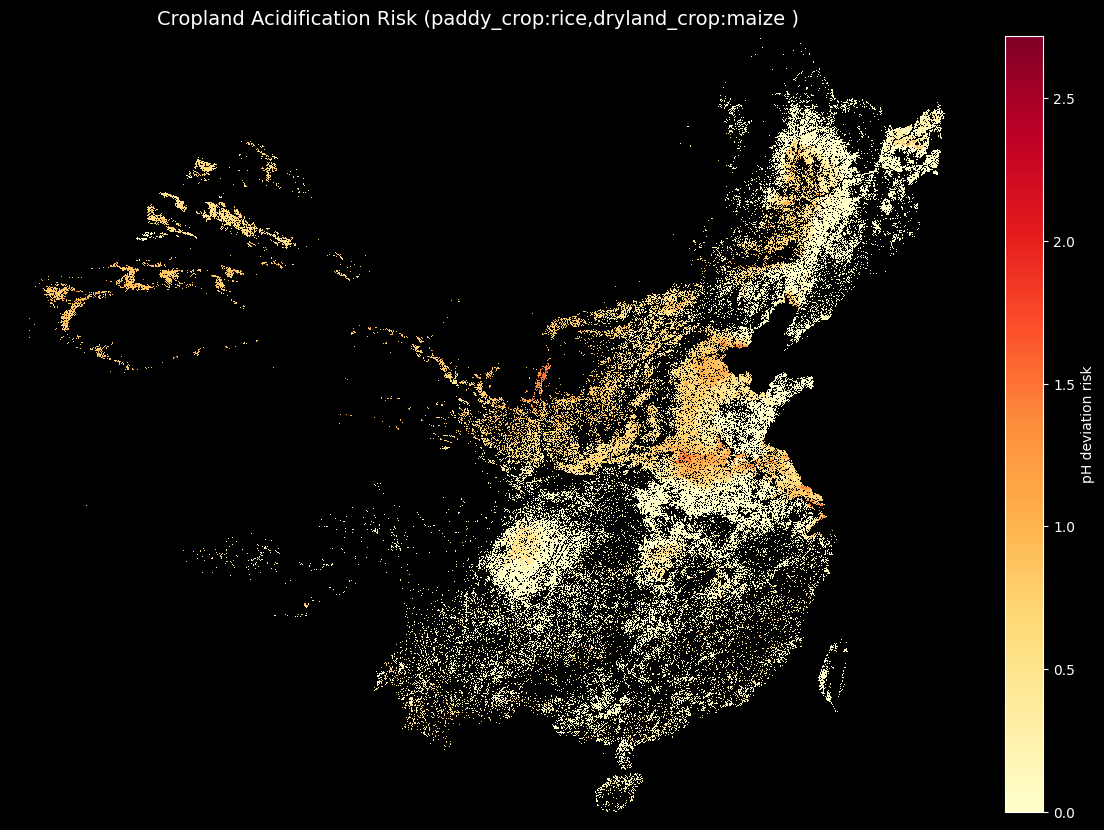

<Figure size 640x480 with 0 Axes>

In [4]:


import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import load_raster
from risk_model import calc_acid_risk

# 1. 加载数据
lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_path = r'C:\projects\soil_acid_risk\data\pH_aligned.tif'
crop_path = r'C:\projects\soil_acid_risk\data\crop_ph.csv'

lu_data, lu_transform, _ = load_raster(lu_path)
ph_data, _, _ = load_raster(ph_path)
crop_df = pd.read_csv(crop_path)

# 计算风险
risk_array, stats = calc_acid_risk(lu_data, ph_data, crop_df, paddy_crop="水稻",dryland_crop="玉米")

print("\n酸化风险统计(双作物)：")
for k, v in stats.items():
    print(f"{k}: {v}")

#  画热力图（只显示有风险的地方）
plt.figure(figsize=(12, 10))
risk_show = np.where(~np.isnan(risk_array), risk_array, np.nan)
plt.imshow(risk_show, cmap='YlOrRd',interpolation='nearest')
plt.colorbar(label='pH deviation risk',shrink=0.8)
plt.title('Cropland Acidification Risk (paddy_crop:rice,dryland_crop:maize )',fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
plt.savefig(r"C:\projects\soil_acid_risk\outputs\risk_map_final.png",dpi=150)

从这张图中我们就可以看出华北平原和长三角地区北部是最严重的地方

In [2]:
import geopandas as gpd
import os
shp_dir = r"C:\projects\soil_acid_risk\data\county_shp"
shp_files = [f for f in os.listdir(shp_dir) if f.endswith('.shp')]
print("找到的shp文件：",shp_files)
if shp_files:
    shp_path = os.path.join(shp_dir,shp_files[0])
    gdf = gpd.read_file(shp_path)
    print("\n字段明列表：",gdf.columns.tolist())
    print("\n前两行数据：")
    print(gdf.head(2))

找到的shp文件： ['shi2022.shp']

字段明列表： ['省', '省代码', '市', '市代码', '市类型', '省类型', '面积', 'geometry']

前两行数据：
     省     省代码    市     市代码  市类型 省类型       面积  \
0  安徽省  340000  安庆市  340800  地级市   省  13488.8   
1  安徽省  340000  蚌埠市  340300  地级市   省   5968.4   

                                            geometry  
0  POLYGON ((1128887.733 3379327.99, 1129097.606 ...  
1  POLYGON ((1115664.2 3634752.93, 1115765.856 36...  


In [1]:
import sys
sys.path.append(r'C:\projects\soil_acid_risk\src')
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import load_raster
from risk_model import calc_acid_risk, calc_county_risk

# 加载数据
lu_path = r'C:\projects\soil_acid_risk\data\landuse_2023.tif'
ph_path = r'C:\projects\soil_acid_risk\data\pH_aligned.tif'
crop_path = r'C:\projects\soil_acid_risk\data\crop_ph.csv'

lu_data, lu_transform, _ = load_raster(lu_path)
ph_data, _, _ = load_raster(ph_path)
crop_df = pd.read_csv(crop_path)

# 计算风险
risk_array, stats = calc_acid_risk(lu_data, ph_data, crop_df)

# 市级统计
shp_path = r'C:\projects\soil_acid_risk\data\city_shp\shi2022.shp'
city_risk = calc_county_risk(risk_array, lu_transform, shp_path)

print("\n========== 酸化风险最高10个市 ==========")
top10 = city_risk.sort_values("mean_risk", ascending=False).head(10)
for _, row in top10.iterrows():
    print(f"{row['county_name']}: 平均风险={row['mean_risk']}, 高风险占比={row['high_risk_ratio(%)']}%")

水稻假设作物: 水稻, 最适pH范围: 5.5 - 7.0
水稻假设作物: 玉米, 最适pH范围: 6.0 - 7.5

========== 酸化风险最高10个市 ==========
石嘴山市: 平均风险=1.4323, 高风险占比=99.62%
银川市: 平均风险=1.3117, 高风险占比=99.77%
开封市: 平均风险=1.2127, 高风险占比=99.49%
商丘市: 平均风险=1.0253, 高风险占比=99.4%
沧州市: 平均风险=0.9521, 高风险占比=99.95%
吴忠市: 平均风险=0.9473, 高风险占比=99.98%
海西蒙古族藏族自治州: 平均风险=0.9229, 高风险占比=97.05%
中卫市: 平均风险=0.8821, 高风险占比=99.57%
阿拉尔市: 平均风险=0.8765, 高风险占比=100.0%
乌海市: 平均风险=0.8593, 高风险占比=99.32%


In [2]:
city_risk.to_csv(
    r'C:\projects\soil_acid_risk\outputs\city_risk_ranking.csv',index=False,encoding = "utf-8-sig"
)
print("市级风险排行已保存到outputs/city_risk")

市级风险排行已保存到outputs/city_risk


## 分析结论

### 1. 全国耕地酸化风险概况
- 基于假设“水田种水稻、旱地种玉米”，全国耕地中约有 **54.11%** 的面积土壤 pH 偏离了作物的最适范围。
- 平均风险偏离度为 **0.30 pH 单位**，说明大部分耕地处于轻微至中度偏离状态。
- 最大偏离度达 **2.72 pH 单位**，局部地区土壤酸碱度与作物需求严重不匹配。

### 2. 高风险区域分布
- 从市级排名来看，高风险区域主要集中在 **北方地区**，尤其是宁夏、河南、河北、青海等省份。
- 风险最高的 5 个市为：石嘴山市、银川市、开封市、商丘市、沧州市。
- 这些城市的高风险面积占比均超过 **99%**，耕地几乎整体处于酸碱不适宜状态。
- 北方土壤多为碱性，而水稻和玉米的最适 pH 范围偏中性（5.5-7.5），这解释了北方城市风险值显著偏高的原因。

### 3. 政策建议
- **高风险区**：建议优先进行土壤改良，如施用酸性肥料、石膏等，降低土壤 pH 值。
- **作物调整**：在碱化严重的区域，可考虑推广更耐碱的作物品种，如甜菜、向日葵、棉花等。
- **精细化分析**：后续可结合县级数据、实际种植结构，进一步细化风险评估，为精准农业提供支持。

### 4. 局限性说明
- 作物假设基于理想情况（水田=水稻，旱地=玉米），实际种植结构可能因地区而异。
- pH 数据来自全国尺度栅格产品，可能存在局部精度不足的问题。
- 风险模型仅考虑 pH 偏离度，未纳入土壤养分、气候等其他因素。